# Weighted Essentially Non-Oscillatory (WENO) Reconstruction
High-order finite volume methods require reconstructing the solution at cell interfaces.
For example, to compute the numerical flux at
$
u_{i+\frac12}
$
we must reconstruct a high-order approximation from nearby cell averages.
However, high-order polynomial reconstructions may produce oscillations near discontinuities.
WENO schemes solve this problem by:
- using multiple candidate stencils
- assigning nonlinear weights based on smoothness
The method ensures that stencils containing discontinuities receive very small weights.

# Reconstruction Target
In a finite volume scheme we store cell averages
$
\bar{u}_i
$
To compute fluxes we reconstruct the value at the interface
$
u_{i+\frac12}^{L}
$
For WENO5, the reconstruction uses five cells
$
{i-2, i-1, i, i+1, i+2}
$
but they are divided into three smaller substencils.

# Three Substencils
The large stencil is split into:
### Stencil 0
$
S_0 = {i-2, i-1, i}
$
### Stencil 1
$
S_1 = {i-1, i, i+1}
$
### Stencil 2
$
S_2 = {i, i+1, i+2}
$
Each stencil produces a third-order approximation of
$
u_{i+\frac12}
$

# Derivation of WENO Substencil Reconstructions (Finite Volume Form)
In finite volume methods we store cell averages

$
\bar{u}_i =
\frac{1}{\Delta x}
\int_{x_{i-\frac12}}^{x_{i+\frac12}} u(x),dx
$

To compute the numerical flux we must reconstruct the point value at the interface
$
u_{i+\frac12}
$
WENO5 uses three substencils, each containing three cell averages, and constructs a quadratic polynomial that preserves these averages.

# Stencil 0
$
S_0 = {i-2,i-1,i}
$
We construct a quadratic polynomial
$
p_0(x) = a_0 + a_1 x + a_2 x^2
$
such that its cell averages match the known values

$
\frac{1}{\Delta x}
\int_{x_{i-5/2}}^{x_{i-3/2}} p_0(x),dx = \bar{u}_{i-2}
$

$
\frac{1}{\Delta x}
\int_{x_{i-3/2}}^{x_{i-1/2}} p_0(x),dx = \bar{u}_{i-1}
$

$
\frac{1}{\Delta x}
\int_{x_{i-1/2}}^{x_{i+1/2}} p_0(x),dx = \bar{u}_i
$


Solving these constraints determines the coefficients
$
a_0,a_1,a_2
$
The interface value is then obtained by evaluating

$
q_0 = p_0(x_{i+\frac12})
$


This produces

$$
q_0 =
\frac{1}{3}\bar{u}_{i-2}
-
\frac{7}{6}\bar{u}_{i-1}
+
\frac{11}{6}\bar{u}_i
$$


# Stencil 1
$
S_1 = {i-1,i,i+1}
$

Construct polynomial

$
p_1(x) = b_0 + b_1 x + b_2 x^2
$

satisfying

$
\frac{1}{\Delta x}
\int_{x_{i-3/2}}^{x_{i-1/2}} p_1(x),dx = \bar{u}_{i-1}
$

$
\frac{1}{\Delta x}
\int_{x_{i-1/2}}^{x_{i+1/2}} p_1(x),dx = \bar{u}_i
$

$
\frac{1}{\Delta x}
\int_{x_{i+1/2}}^{x_{i+3/2}} p_1(x),dx = \bar{u}_{i+1}
$

Evaluating the polynomial at
$
x_{i+\frac12}
$
gives

$$
q_1 =
-\frac{1}{6}\bar{u}_{i-1}
+
\frac{5}{6}\bar{u}_i
+
\frac{1}{3}\bar{u}_{i+1}
$$


# Stencil 2
$
S_2 = {i,i+1,i+2}
$
Construct polynomial
$
p_2(x)
$
such that
$$
\frac{1}{\Delta x}
\int_{x_{i-1/2}}^{x_{i+1/2}} p_2(x),dx = \bar{u}_i
$$

$
\frac{1}{\Delta x}
\int_{x_{i+1/2}}^{x_{i+3/2}} p_2(x),dx = \bar{u}_{i+1}
$

$
\frac{1}{\Delta x}
\int_{x_{i+3/2}}^{x_{i+5/2}} p_2(x),dx = \bar{u}_{i+2}
$

Evaluating at the interface gives
$$
q_2 =
\frac{1}{3}\bar{u}_i
+
\frac{5}{6}\bar{u}_{i+1}
-
\frac{1}{6}\bar{u}_{i+2}
$$

# Result
The three substencil reconstructions are
$$
q_0 =
\frac{1}{3}\bar{u}_{i-2}
-
\frac{7}{6}\bar{u}_{i-1}
+
\frac{11}{6}\bar{u}_i
$$

$$
q_1 =
-\frac{1}{6}\bar{u}_{i-1}
+
\frac{5}{6}\bar{u}_i
+
\frac{1}{3}\bar{u}_{i+1}
$$

$$
q_2 =
\frac{1}{3}\bar{u}_i
+
\frac{5}{6}\bar{u}_{i+1}
-
\frac{1}{6}\bar{u}_{i+2}
$$



Now we have three substencils of WENO, please noe that they are not based on standadrd interpolation formula. These are cell-averaged interpolation formula. Now we shall test, how good they are in calculating $u_{i+0.5}$ on a step like function. 

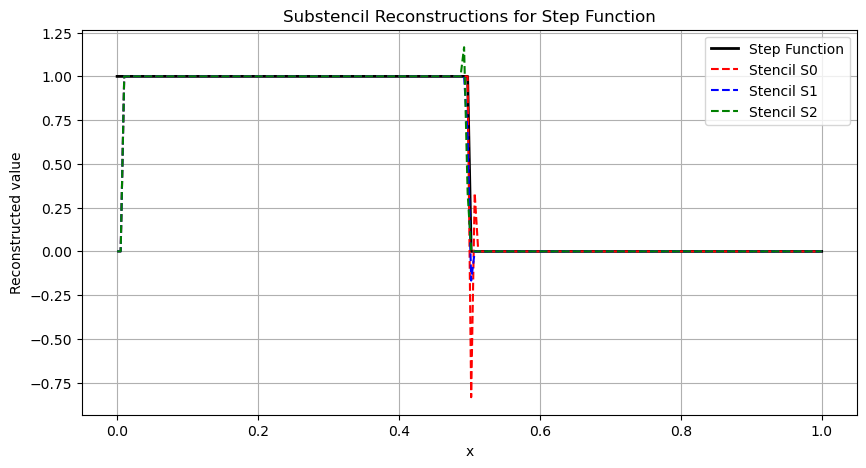

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# %%
from IPython.display import HTML
plt.rcParams["animation.html"] = "jshtml"

# --------------------------------------------------
# Grid
# --------------------------------------------------

nx = 200
x = np.linspace(0,1,nx)

dx = x[1]-x[0]

# --------------------------------------------------
# Step function
# --------------------------------------------------

u = np.zeros(nx)
u[x < 0.5] = 1

# --------------------------------------------------
# Interface points
# --------------------------------------------------

x_interface = x[:-1] + dx/2

# Arrays for substencil reconstructions

q0 = np.zeros(nx)
q1 = np.zeros(nx)
q2 = np.zeros(nx)

# --------------------------------------------------
# Compute reconstructions
# --------------------------------------------------

for i in range(2,nx-2):

    q0[i] = (1/3)*u[i-2] \
          - (7/6)*u[i-1] \
          + (11/6)*u[i]

    q1[i] = -(1/6)*u[i-1] \
          + (5/6)*u[i] \
          + (1/3)*u[i+1]

    q2[i] = (1/3)*u[i] \
          + (5/6)*u[i+1] \
          - (1/6)*u[i+2]

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(x,u,'k',linewidth=2,label='Step Function')

plt.plot(x,q0,'r--',label='Stencil S0')
plt.plot(x,q1,'b--',label='Stencil S1')
plt.plot(x,q2,'g--',label='Stencil S2')

plt.xlabel('x')
plt.ylabel('Reconstructed value')

plt.title('Substencil Reconstructions for Step Function')

plt.legend()
plt.grid()

plt.show()

In the above figure, we observe that at least one sub stencil is not showing oscillations at a particular x value.In the above figure green is oscillating at the top, it is not oscillating at the bottom. Similarly Red and Blue are showing oscillation at bottom not at top.  If we carefully eliminate the oscillatory polynomial in the reconstruction step, we can avoid oscillations in the reconstruction step. If the stencil is non-smooth, it will produce high slope and curvature. This is measured using a smoothness indicator

# Key Idea
Suppose a discontinuity occurs between
$
i
$
and
$
i+1
$
Then:
- stencil $S_2$ crosses the discontinuity
- stencil $S_1$ may partially see it
- stencil $S_0$ remains smooth
Therefore:
- $q_0$ is non-oscillatory
- $q_2$ is oscillatory
The WENO method detects this automatically.

# Smoothness Indicators
WENO measures the smoothness of each stencil using
$
\beta_k
$
Large values indicate high oscillation.

$
\beta_0 =
\frac{13}{12}(u_{i-2}-2u_{i-1}+u_i)^2
+
\frac14(u_{i-2}-4u_{i-1}+3u_i)^2
$


$
\beta_1 =
\frac{13}{12}(u_{i-1}-2u_i+u_{i+1})^2
+
\frac14(u_{i-1}-u_{i+1})^2
$


$
\beta_2 =
\frac{13}{12}(u_i-2u_{i+1}+u_{i+2})^2
+
\frac14(3u_i-4u_{i+1}+u_{i+2})^2
$

# Nonlinear Weights
Ideal linear weights
$
d_0=\frac{1}{10},\quad
d_1=\frac{6}{10},\quad
d_2=\frac{3}{10}
$
Nonlinear weights:
$
\alpha_k =
\frac{d_k}{(\epsilon+\beta_k)^2}
$
$
\omega_k =
\frac{\alpha_k}{\sum \alpha_k}
$

# Final WENO Reconstruction

$$
u_{i+\frac12}^L
=
\omega_0 q_0
+
\omega_1 q_1
+
\omega_2 q_2
$$
Properties:
- 5th order accuracy in smooth regions
- automatically avoids oscillatory stencils
- robust near shocks

# Key Intuition
WENO works because:
- At least one stencil remains smooth
- Oscillatory stencils receive very small weights
- Smooth stencils dominate the reconstruction
This produces high-order accuracy without Gibbs oscillations.

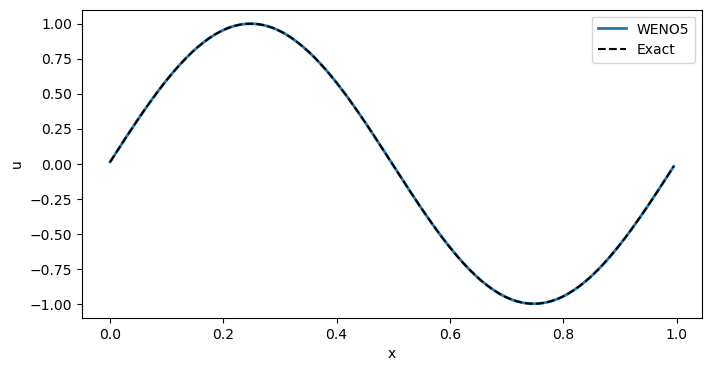

In [3]:
# %% [markdown]
# # Linear Convection using WENO5
#
# This notebook solves the **1D linear convection equation**
#
# $$
# \frac{\partial u}{\partial t} + a \frac{\partial u}{\partial x} = 0
# $$
#
# using a **finite volume scheme with WENO5 reconstruction**.
#
# ## Features
#
# - WENO5 spatial discretization
# - SSPRK3 time integration
# - Hat function initial condition
# - Periodic boundary conditions
# - Comparison with analytical solution
# - Animation of the solution

# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# %% [markdown]
# # Grid Setup

# %%
nx = 200
xmin = 0
xmax = 1

x = np.linspace(xmin, xmax, nx, endpoint=False)
dx = (xmax-xmin)/nx

a = 1.0

CFL = 0.4
dt = CFL*dx/abs(a)

t_final = 1.0
nt = int(t_final/dt)

# %% [markdown]
# # Initial Condition (Hat Function)

# %%
def initial_condition(x):
    return np.sin(2*np.pi*x)

# %% [markdown]
# # Exact Solution

# %%
def exact_solution(x,t):
    return np.sin(2*np.pi*(x-a*t))

# %% [markdown]
# # WENO5 Reconstruction

# %%
def weno5_flux(u):

    eps = 1e-6

    u_ext = np.concatenate((u[-3:],u,u[:3]))

    flux = np.zeros(len(u)+1)

    for i in range(2,len(u)+3):

        v0 = u_ext[i-2]
        v1 = u_ext[i-1]
        v2 = u_ext[i]
        v3 = u_ext[i+1]
        v4 = u_ext[i+2]

        # candidate polynomials
        q0 = (1/3)*v0 - (7/6)*v1 + (11/6)*v2
        q1 = -(1/6)*v1 + (5/6)*v2 + (1/3)*v3
        q2 = (1/3)*v2 + (5/6)*v3 - (1/6)*v4

        # smoothness indicators
        b0 = (13/12)*(v0-2*v1+v2)**2 + 0.25*(v0-4*v1+3*v2)**2
        b1 = (13/12)*(v1-2*v2+v3)**2 + 0.25*(v1-v3)**2
        b2 = (13/12)*(v2-2*v3+v4)**2 + 0.25*(3*v2-4*v3+v4)**2

        d0 = 0.1
        d1 = 0.6
        d2 = 0.3

        a0 = d0/(eps + b0)**2
        a1 = d1/(eps + b1)**2
        a2 = d2/(eps + b2)**2

        den = a0 + a1 + a2 + 1e-16

        w0 = a0/den
        w1 = a1/den
        w2 = a2/den

        u_half = w0*q0 + w1*q1 + w2*q2

        flux[i-2] = a*u_half

    return flux
# %% [markdown]
# # RHS Function

# %%
def compute_rhs(u):

    flux = weno5_flux(u)

    rhs = -(flux[1:] - flux[:-1])/dx

    return rhs

# %% [markdown]
# # SSPRK3 Time Integration

# %%
def step(u):

    k1 = compute_rhs(u)
    u1 = u + dt*k1

    k2 = compute_rhs(u1)
    u2 = 0.75*u + 0.25*(u1 + dt*k2)

    k3 = compute_rhs(u2)
    unew = (1/3)*u + (2/3)*(u2 + dt*k3)

    return unew

# %% [markdown]
# # Time Integration

# %%
u = initial_condition(x)

solutions = []
time = []

for n in range(nt):

    solutions.append(u.copy())
    time.append(n*dt)

    u = step(u)

solutions = np.array(solutions)
# %%
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))

line_num, = ax.plot(x,solutions[-1],lw=2,label="WENO5")
line_exact, = ax.plot(x,exact_solution(x,time[-1]),'k--',label="Exact")

# ax.set_xlim(0,1)
# ax.set_ylim(-0.1,1.2)

ax.set_xlabel("x")
ax.set_ylabel("u")
ax.legend()

plt.show()
# def update(frame):

#     t = time[frame]

#     u_exact = exact_solution(x,t)

#     line_num.set_data(x,solutions[frame])
#     line_exact.set_data(x,u_exact)

#     ax.set_title(f"time = {t:.3f}")

#     return line_num,line_exact

# anim = FuncAnimation(fig,update,frames=len(time),interval=40)

# HTML(anim.to_jshtml())

## Point-wise rate of convergence Calculation

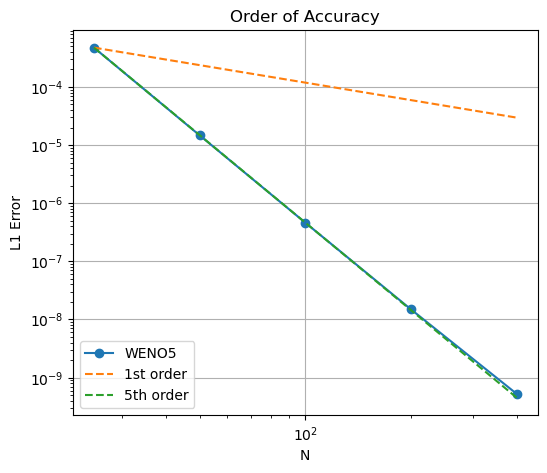

Errors: [4.74527848e-04 1.47129412e-05 4.62476016e-07 1.49179434e-08
 5.25811795e-10]
Observed order: [5.01133518 4.99156332 4.95425798 4.82635835]


In [4]:
# %% [markdown]
# # Order of Accuracy Study

# %%

def solve(nx):

    xmin = 0
    xmax = 1

    x = np.linspace(xmin, xmax, nx, endpoint=False)
    dx = (xmax-xmin)/nx

    a = 1.0

    CFL = 0.4
    dt = CFL*dx/abs(a)

    t_final = 1.0
    nt = int(t_final/dt)

    u = initial_condition(x)

    for n in range(nt):
        u = step(u)

    u_exact = exact_solution(x,nt*dt)

    err = np.sum(np.abs(u-u_exact))*dx

    return err


# grid sizes
N_list = [25,50,100,200,400]

errors = []

for N in N_list:

    nx = N

    xmin = 0
    xmax = 1

    x = np.linspace(xmin, xmax, nx, endpoint=False)
    dx = (xmax-xmin)/nx

    a = 1.0

    CFL = 0.05
    dt = CFL*dx/abs(a)

    t_final = 1.0
    nt = int(t_final/dt)

    u = initial_condition(x)

    for n in range(nt):
        u = step(u)

    u_exact = exact_solution(x,nt*dt)

    # err = np.mean(np.abs(u-u_exact))*dx
    err = np.mean(np.abs(u-u_exact))

    errors.append(err)

errors = np.array(errors)

# %% plot

plt.figure(figsize=(6,5))

plt.loglog(N_list,errors,'o-',label="WENO5")

# reference slopes
ref1 = errors[0]*(np.array(N_list)/N_list[0])**(-1)
ref5 = errors[0]*(np.array(N_list)/N_list[0])**(-5)

plt.loglog(N_list,ref1,'--',label="1st order")
plt.loglog(N_list,ref5,'--',label="5th order")

plt.xlabel("N")
plt.ylabel("L1 Error")

plt.title("Order of Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# compute observed order

orders = np.log(errors[:-1]/errors[1:]) / np.log(np.array(N_list[1:])/np.array(N_list[:-1]))

print("Errors:",errors)
print("Observed order:",orders)

## Cell averagred rate of convergence Calculation

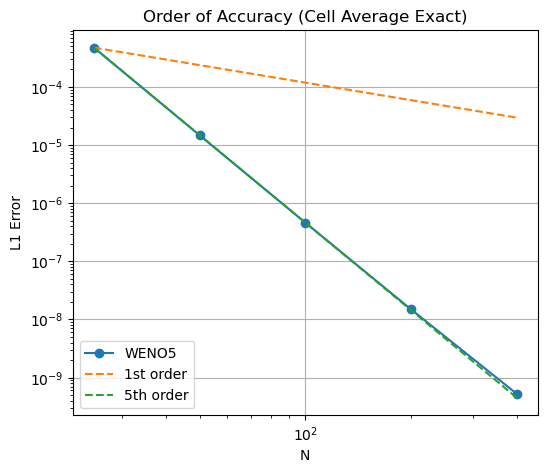

Errors: [4.73279893e-04 1.47032613e-05 4.62399913e-07 1.49173293e-08
 5.25807079e-10]
Observed order: [5.00848553 4.99085126 4.95407995 4.82631189]


In [5]:
# %% [markdown]
# # Order of Accuracy Study (Cell Average Exact Solution)

# %%
import numpy as np
import matplotlib.pyplot as plt


# %% ---------------------------------------------------------
# Exact cell average using Gaussian quadrature
# ---------------------------------------------------------

def exact_cell_average(x, t, dx, nq=6):
    """
    Computes the exact cell average for the 1D advection equation.
    u(x,t) = u_0( (x - at - xmin) % L + xmin )
    """
    # Domain length for periodic wrapping
    L = xmax - xmin
    
    # Standard Gauss-Legendre points and weights on [-1, 1]
    xi, wi = np.polynomial.legendre.leggauss(nq)
    
    ubar = np.zeros_like(x)
    
    for i, xc in enumerate(x):
        # 1. Define cell boundaries
        xl_cell = xc - dx/2
        xr_cell = xc + dx/2
        
        # 2. Map quadrature points from [-1, 1] to [xl_cell, xr_cell]
        # x_quad = mid + half_width * xi
        x_quad = xc + (dx/2) * xi
        
        # 3. Apply the exact solution: u(x, t) = u_0(x - a*t)
        x_shifted = xmin + (x_quad - a*t - xmin) % L
        
        vals = initial_condition(x_shifted)
        
        # 4. Integrate and average
        ubar[i] = 0.5 * np.sum(wi * vals)
        
    return ubar

# %% ---------------------------------------------------------
# Order study
# ---------------------------------------------------------

N_list = [25,50,100,200,400]

errors = []

for nx in N_list:

    x = np.linspace(xmin,xmax,nx,endpoint=False)
    dx = (xmax-xmin)/nx

    dt = CFL*dx/abs(a)
    nt = int(t_final/dt)

    # initialize with cell averages
    u = exact_cell_average(x,0,dx)

    for n in range(nt):
        u = step(u)

    u_exact = exact_cell_average(x,nt*dt,dx)

    # err = np.sum(np.abs(u-u_exact))*dx
    err = np.mean(np.abs(u-u_exact))

    errors.append(err)

errors = np.array(errors)

# %% plot

plt.figure(figsize=(6,5))

plt.loglog(N_list,errors,'o-',label="WENO5")

ref1 = errors[0]*(np.array(N_list)/N_list[0])**(-1)
ref5 = errors[0]*(np.array(N_list)/N_list[0])**(-5)

plt.loglog(N_list,ref1,'--',label="1st order")
plt.loglog(N_list,ref5,'--',label="5th order")

plt.xlabel("N")
plt.ylabel("L1 Error")

plt.title("Order of Accuracy (Cell Average Exact)")

plt.legend()
plt.grid(True)

plt.show()


# %% observed order

orders = np.log(errors[:-1]/errors[1:]) / np.log(np.array(N_list[1:])/np.array(N_list[:-1]))

print("Errors:",errors)
print("Observed order:",orders)